In [1]:
from deepface import DeepFace
import matplotlib.pyplot as plt
import os
import cv2

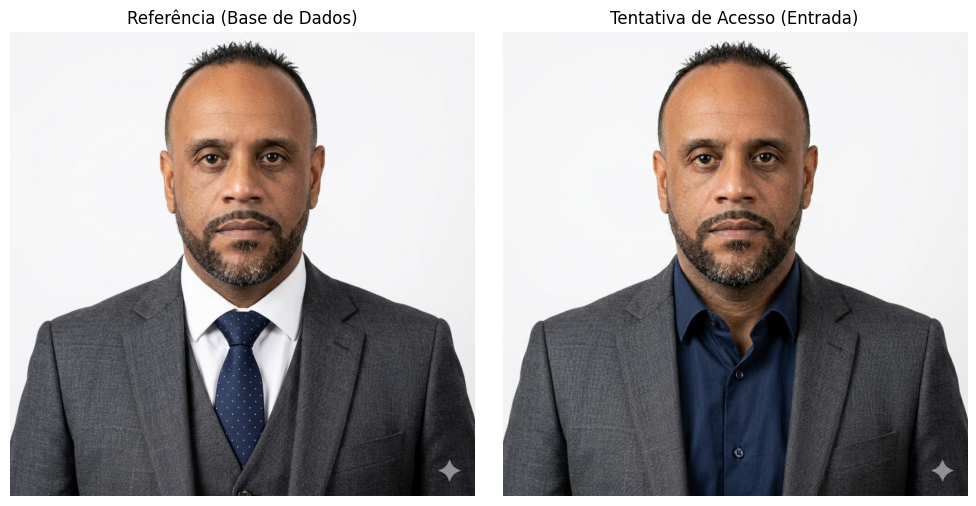

In [2]:
img_referencia_caminho = r'C:\Users\Augusto\Curso_Senai\Projeto Integrador\imagens\imagem_1.png'
img_teste_caminho = r'C:\Users\Augusto\Curso_Senai\Projeto Integrador\imagens\imagem_2.png'

img_ref = cv2.imread(img_referencia_caminho)
img_test = cv2.imread(img_teste_caminho)

img_ref = cv2.cvtColor(img_ref, cv2.COLOR_BGR2RGB)
img_test = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB) 

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_ref)
axes[0].set_title("Referência (Base de Dados)")
axes[0].axis('off')

axes[1].imshow(img_test)
axes[1].set_title("Tentativa de Acesso (Entrada)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [3]:
print("Iniciando a verificação facial... Aguarde.")

try:
    # Utilizando o modelo VGG-Face (padrão do DeepFace) para verificar a similaridade
    resultado = DeepFace.verify(
        img1_path = img_referencia_caminho,
        img2_path = img_teste_caminho,
        model_name = "VGG-Face",
        distance_metric = "cosine"
    )

    # Extraindo métricas importantes do dicionário de retorno
    face_verificada = resultado["verified"]
    distancia = resultado["distance"]
    threshold = resultado["threshold"]

    print("\n--- Métricas da Comparação ---")
    print(f"Mesma pessoa? {face_verificada}")
    print(f"Distância de Cosseno calculada: {distancia:.4f}")
    print(f"Limiar (Threshold) máximo permitido: {threshold}")

except Exception as e:
    print(f"Erro ao processar as imagens: {e}. Verifique se há rostos visíveis em ambas as fotos.")

Iniciando a verificação facial... Aguarde.
26-06-14 15:01:26 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to C:\Users\Augusto\.deepface\weights\vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: C:\Users\Augusto\.deepface\weights\vgg_face_weights.h5
100%|██████████| 580M/580M [00:51<00:00, 11.2MB/s] 



--- Métricas da Comparação ---
Mesma pessoa? True
Distância de Cosseno calculada: 0.0552
Limiar (Threshold) máximo permitido: 0.68


In [4]:
if face_verificada:
    status_acesso = "ACESSO AUTORIZADO"
    cor_alerta = (0, 255, 0) # Verde em RGB/BGR para o feedback visual posterior
else:
    status_acesso = "ACESSO NEGADO"
    cor_alerta = (255, 0, 0) # Vermelho

print(f"Resultado do Sistema: {status_acesso}")

Resultado do Sistema: ACESSO AUTORIZADO


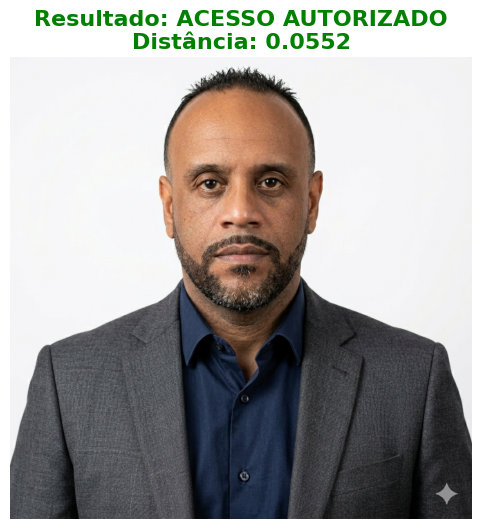

          LOG DE CONTROLE DE ACESSO       
Status Final:  ACESSO AUTORIZADO
Confiabilidade: Métrica de distância em 0.0552


In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(img_test)
plt.title(f"Resultado: {status_acesso}\nDistância: {distancia:.4f}",
          color='green' if face_verificada else 'red',
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

# Resumo textual em formato de log industrial
print("=========================================")
print("          LOG DE CONTROLE DE ACESSO       ")
print("=========================================")
print(f"Status Final:  {status_acesso}")
print(f"Confiabilidade: Métrica de distância em {distancia:.4f}")
print("=========================================")